In [1]:
from matplotlib import pyplot as plt

import numpy as np

import pandas as pd

In [2]:
def gen_auroc_cols(num_classes, prefix):
    return list(
        map(
            lambda i: f"{prefix}_auroc_c{i}",
            range(num_classes)
        )
    )
gen_auroc_cols(6, "orig")

['orig_auroc_c0',
 'orig_auroc_c1',
 'orig_auroc_c2',
 'orig_auroc_c3',
 'orig_auroc_c4',
 'orig_auroc_c5']

In [3]:
def load_data(
    model_name,
    layer,
    dataset_name,
    basis_name,
):
    df = pd.read_csv(f"../../artifacts/2024-11-s42-2024-11-s42--selected-classes-and-others/experiments/one-vs-all/{dataset_name}/{model_name}/{layer}/{basis_name}--uncentered/accuracy.csv")

    num_classes = len(list(
        filter(lambda c: "orig_auroc_c" in c, df.columns)
    ))



    for prefix in ["orig", "train", "val"]:
        cols = gen_auroc_cols(num_classes, prefix)
        df[f"{prefix}_auroc_mean"] = df[cols].mean(axis=1)
        df[f"{prefix}_auroc_median"] = df[cols].median(axis=1)
        df[f"{prefix}_auroc_min"] = df[cols].min(axis=1)
    
    return df
    
_df = load_data(
    model_name="cifar100-resnet18-v1",
    layer="layer3",
    dataset_name="cifar100-c71-and-others",
    basis_name="pca"
)
_df 

,k,orig_loss,orig_accuracy,orig_auroc_c0,orig_auroc_c1,train_loss,train_acc,train_auroc_c0,train_auroc_c1,val_loss,...,val_auroc_c1,orig_auroc_mean,orig_auroc_median,orig_auroc_min,train_auroc_mean,train_auroc_median,train_auroc_min,val_auroc_mean,val_auroc_median,val_auroc_min
0,1,0.013817,0.9968,0.982308,0.983553,0.227881,0.99000,0.588357,0.588363,0.227633,...,0.601322,0.982931,0.982931,0.982308,0.588360,0.588360,0.588357,0.601322,0.601322,0.601322
1,3,0.013817,0.9968,0.982308,0.983553,0.167982,0.99000,0.565849,0.565849,0.168043,...,0.540512,0.982931,0.982931,0.982308,0.565849,0.565849,0.565849,0.540512,0.540512,0.540512
2,5,0.013817,0.9968,0.982308,0.983553,0.161986,0.98994,0.563404,0.563404,0.162246,...,0.560591,0.982931,0.982931,0.982308,0.563404,0.563404,0.563404,0.560591,0.560591,0.560591
3,7,0.013817,0.9968,0.982308,0.983553,0.148035,0.99000,0.540290,0.540290,0.147558,...,0.540458,0.982931,0.982931,0.982308,0.540290,0.540290,0.540290,0.540458,0.540458,0.540458
4,9,0.013817,0.9968,0.982308,0.983553,0.116418,0.99046,0.778816,0.778816,0.116638,...,0.779248,0.982931,0.982931,0.982308,0.778816,0.778816,0.778816,0.779248,0.779248,0.779247
5,11,0.013817,0.9968,0.982308,0.983553,0.094673,0.99194,0.897471,0.897471,0.096184,...,0.884304,0.982931,0.982931,0.982308,0.897471,0.897471,0.897471,0.884304,0.884304,0.884304
6,13,0.013817,0.9968,0.982308,0.983553,0.073704,0.99394,0.957677,0.957677,0.077888,...,0.931657,0.982931,0.982931,0.982308,0.957677,0.957677,0.957677,0.931656,0.931656,0.931655
7,15,0.013817,0.9968,0.982308,0.983553,0.053104,0.99396,0.980551,0.980552,0.057643,...,0.969533,0.982931,0.982931,0.982308,0.980552,0.980552,0.980551,0.969532,0.969532,0.969531
8,17,0.013817,0.9968,0.982308,0.983553,0.038926,0.99518,0.986039,0.986040,0.045564,...,0.960905,0.982931,0.982931,0.982308,0.986040,0.986040,0.986039,0.960902,0.960902,0.960898
9,19,0.013817,0.9968,0.982308,0.983553,0.025308,0.99654,0.992910,0.992910,0.033994,...,0.963324,0.982931,0.982931,0.982308,0.992910,0.992910,0.992910,0.963312,0.963312,0.963300


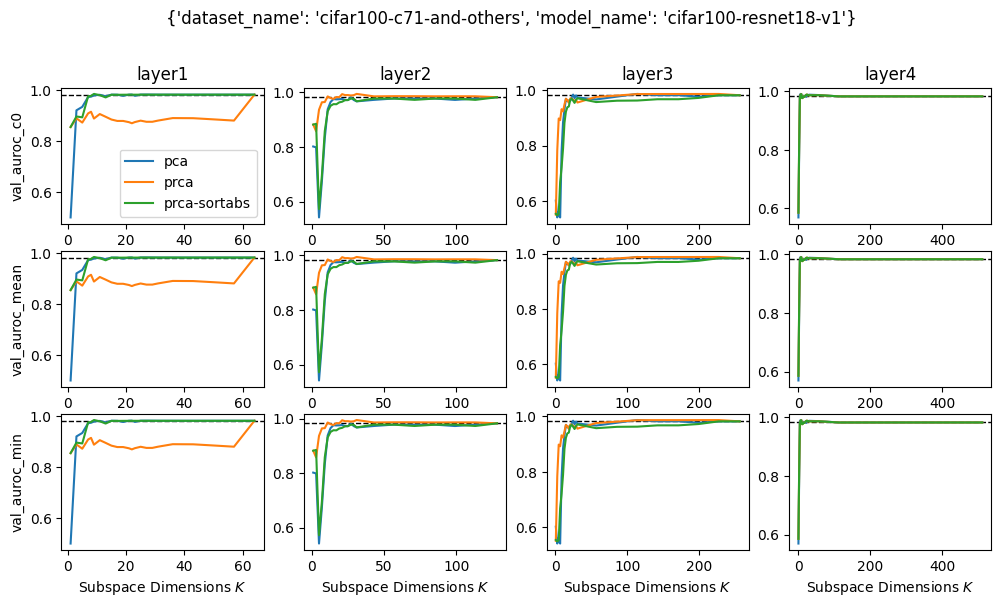

In [9]:
def viz(
    dataset_name,
    model_name="cifar100-resnet18-v1",
    arr_layers=[
        "layer1", "layer2", 
        "layer3", 
        "layer4"
    ]
):

    arr_attrs = [
        # "val_loss", 
        # "val_acc",
        "val_auroc_c0",
        "val_auroc_mean",
        # "val_auroc_median",
        "val_auroc_min",
    ]
    ncols = len(arr_layers)
    nrows = len(arr_attrs)
    plt.figure(figsize=(3*ncols, 2*nrows))
    query = dict(
            dataset_name=dataset_name,
            model_name=model_name,
        )
    plt.suptitle(query, y=1.01)

    for aix, attr_name in enumerate(arr_attrs):        
        for lix, layer in enumerate(arr_layers):
            plt.subplot(nrows, ncols, aix * ncols + 1 + lix)
            if aix == 0:
                plt.title(f"{layer}")
    
            for bix, basis_name in enumerate(["pca", "prca", "prca-sortabs"]):
                df = load_data(
                    **query,
                    layer=layer,
                    basis_name=basis_name
                )
                if bix == 0:
                    plt.axhline(df[attr_name].values[-1], ls="--", lw=1, color="k")
    
                plt.plot(
                    df.k,
                    df[attr_name],
                    label=basis_name
                )
            if lix == 0:
                plt.ylabel(attr_name)

            if lix == aix == 0:
                plt.legend()
            if aix == nrows - 1:
                plt.xlabel("Subspace Dimensions $K$")
        
viz(
    dataset_name="cifar100-c71-and-others"
)